## Pré-traitement

Basé sur les observations du 1.2 :
- Ratio déséquilibre : **118.9x** (hands vs face-guard)
- **52.3%** des bounding boxes sont petites (< 1% de l'image)
- Images issues de Pexels : haute qualité, aucun grain ni compression visible

**Deux pré-traitements appliqués : redimensionnement (≥ 1024×1024) et normalisation [0.0, 1.0]**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

DATASET_ROOT = Path(r"C:\Users\luigi\OneDrive\Documents\Ecole 18.06\Traitement_image\Projet\SH17dataset")

## 1. Redimensionnement

**Justification :** 52.3% des bounding boxes ont une aire inférieure à 1% de l'image. À basse résolution, un tel objet occupe environ 6×6 pixels, ce qui est insuffisant pour la détection. Une résolution élevée (≥ 1024×1024) préserve les détails des casques, lunettes, gants et autres EPI de petite taille.

La résolution exacte sera confirmée après le choix du modèle. Aucune modification manuelle des images n'est nécessaire — le framework se charge du redimensionnement.

Petites boites analysees : 2387
Taille mediane a  640px  : 28.5 x 28.5 px
Taille mediane a 1024px  : 45.7 x 45.7 px


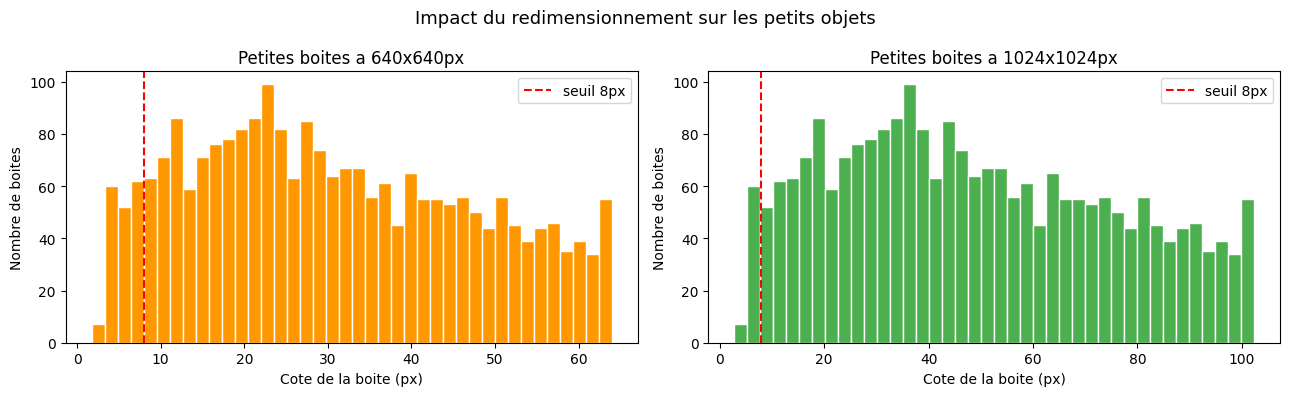

In [2]:
small_px_low  = []
small_px_high = []

random.seed(42)
label_files  = list((DATASET_ROOT / 'labels' / 'train').glob('*.txt'))
sample_files = random.sample(label_files, min(500, len(label_files)))

for lbl_file in sample_files:
    for line in lbl_file.read_text().strip().splitlines():
        if not line:
            continue
        parts = line.split()
        if len(parts) < 5:
            continue
        bw, bh = float(parts[3]), float(parts[4])
        if bw * bh < 0.01:
            small_px_low.append(bw * 640 * bh * 640)
            small_px_high.append(bw * 1024 * bh * 1024)

print(f"Petites boites analysees : {len(small_px_low)}")
print(f"Taille mediane a  640px  : {np.sqrt(np.median(small_px_low)):.1f} x {np.sqrt(np.median(small_px_low)):.1f} px")
print(f"Taille mediane a 1024px  : {np.sqrt(np.median(small_px_high)):.1f} x {np.sqrt(np.median(small_px_high)):.1f} px")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, data, res, color in zip(
    axes,
    [small_px_low, small_px_high],
    [640, 1024],
    ['#FF9800', '#4CAF50']
):
    ax.hist(np.sqrt(data), bins=40, color=color, edgecolor='white')
    ax.set_xlabel('Cote de la boite (px)')
    ax.set_ylabel('Nombre de boites')
    ax.set_title(f'Petites boites a {res}x{res}px')
    ax.axvline(8, color='red', linestyle='--', label='seuil 8px')
    ax.legend()

plt.suptitle('Impact du redimensionnement sur les petits objets', fontsize=13)
plt.tight_layout()
plt.show()

## 2. Normalisation des pixels

**Justification :** tout réseau de neurones de détection requiert des valeurs d'entrée dans un intervalle stable. Les images brutes ont des pixels dans [0, 255] (entiers 8 bits). La normalisation les ramène à [0.0, 1.0] (flottants 32 bits), ce qui stabilise le gradient et accélère la convergence. 

Avant  : dtype=uint8  min=0  max=255
Apres  : dtype=float32  min=0.000  max=1.000


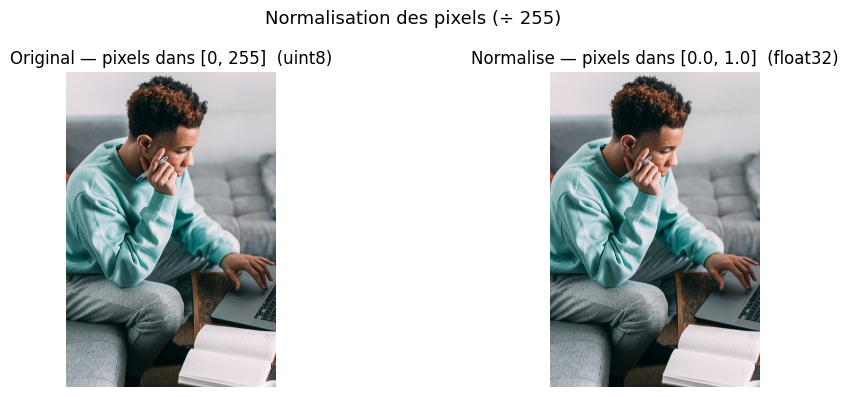

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

DATASET_ROOT = Path(r"C:\Users\luigi\OneDrive\Documents\Ecole 18.06\Traitement_image\Projet\SH17dataset")

random.seed(42)
img_path   = random.choice(list((DATASET_ROOT / 'images' / 'train').glob('*.*')))
img_uint8  = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
img_float  = img_uint8.astype(np.float32) / 255.0

print(f"Avant  : dtype={img_uint8.dtype}  min={img_uint8.min()}  max={img_uint8.max()}")
print(f"Apres  : dtype={img_float.dtype}  min={img_float.min():.3f}  max={img_float.max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img_uint8)
axes[0].set_title(f'Original — pixels dans [0, 255]  (uint8)')
axes[0].axis('off')
axes[1].imshow(img_float)
axes[1].set_title(f'Normalise — pixels dans [0.0, 1.0]  (float32)')
axes[1].axis('off')
plt.suptitle('Normalisation des pixels (÷ 255)', fontsize=13)
plt.tight_layout()
plt.show()

## Récapitulatif

| Pré-traitement | Appliqué | Raison |
|---|---|---|
| Redimensionnement | **Oui** — résolution ≥ 1024×1024 | 52.3% de petites boîtes — résolution exacte à confirmer après choix du modèle |
| Normalisation | **Oui** — pixels dans [0.0, 1.0] | Permet de stabiliser l'entrainement avec une plage de données numérique homogène.  |
| Débruitage | Non | Images Pexels, aucun grain ni compression visible |
| Recadrage | Non | Tous les modèles candidats intègrent une détection multi-échelle |